# Stepup and Imports

In [1]:
import os
import operator

from typing import TypedDict, Annotated, List
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from pathlib import Path

c:\Users\ok\OneDrive\Documents\Agentic AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# LLM Configuration

In [2]:
llm = ChatGroq( 
    model = 'llama-3.3-70b-versatile',
    temperature= 0
)

# Graph State & Task Definition

In [3]:
class Task(BaseModel):
    id : int
    title : str
    description : str = Field(description= 'What to cover tough.')

In [4]:
class Plan(BaseModel):
    blog_title : str
    tasks : List[Task]

In [5]:
class BlogState(TypedDict):
    topic : str
    plan : Plan
    sections : Annotated[List[str], operator.add]
    final : str

In [6]:
struct_llm = llm.with_structured_output(Plan)

# Orchestrator(Planner) Node

In [7]:
def orchestrator(state: BlogState):
    plan = struct_llm.invoke(
        [
            SystemMessage(content='Create a blog plan upto 5-6 sections on the following topic'),
            HumanMessage(content=f'Topic: {state["topic"]}'),
        ]
    )
    return {'plan': plan}

In [ ]:
def distribute_tasks(state: BlogState):
# The 'Send' command is use to send your plan(plan contain tasks) to 'worker' node for processing    
    return [Send('worker', {'task': task, 'topic': state['topic'], 'plan': state['plan']})
            for task in state['plan'].tasks]

# Parallel Worker Logic

In [ ]:
def worker(payload: dict) -> dict:
    # Due to parallel processing we use Payload & Payload contains what we send.

    tasks = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title

    sections = llm.invoke(
        [
            SystemMessage(content='Write 1 clean markdown section.'),
            HumanMessage(content=
                f'Title: {blog_title}\n'
                f'Topic: {topic}\n'
                f'Section: {tasks.title}\n'     # Section is written based on title & description so there i use title..   
                f'Description: {tasks.description}\n'  
                'Return only section content.'
            )
        ]
    ).content.strip()

    return {'sections': [sections]}

# Assembling & File Export:

In [ ]:
# Reducer is used to concatinate the result of workers(sections got together.)

def reducer(state : BlogState) -> dict:
    title = state['plan'].blog_title
    body = '\n\n'.join(s.strip() for s in state['sections'])

    final = f'{title} \n\n {body}'

    filename = title.lower().replace(' ', '_') 
    file_path = Path(filename) # Modern file handling for diff OS.
# Saving file on your disk or pc.
    file_path.write_text(final, encoding= 'utf-8') # utf-8 ensure no error due to emojis & special chars.
    return {'final' : final}

# Main Graph

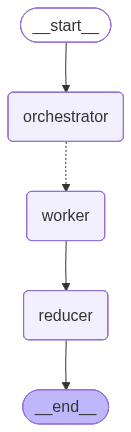

In [11]:
graph = StateGraph(BlogState)

graph.add_node('orchestrator', orchestrator)
graph.add_node('worker', worker)
graph.add_node('reducer', reducer)

graph.add_edge(START, 'orchestrator')
graph.add_conditional_edges('orchestrator', distribute_tasks, ['worker'])
graph.add_edge('worker', 'reducer')
graph.add_edge('reducer', END)

chatbot = graph.compile()
chatbot

# Running

In [ ]:
user_query = chatbot.invoke({
    'topic' : 'Write blog on the topic of Agentic AI.',
    'sections' : [] # This list is the place where all our blog content is located.
})

user_query

{'topic': 'Write blog on the topic of Agentic AI.',
 'plan': Plan(blog_title='Agentic AI: The Future of Artificial Intelligence', tasks=[Task(id=1, title='Introduction to Agentic AI', description='Define Agentic AI, its importance, and brief overview of the topic'), Task(id=2, title='History and Evolution of Agentic AI', description='Discuss the history and evolution of Agentic AI, key milestones, and breakthroughs'), Task(id=3, title='Key Characteristics of Agentic AI', description='Explain the key characteristics of Agentic AI, such as autonomy, agency, and decision-making capabilities'), Task(id=4, title='Applications and Use Cases of Agentic AI', description='Explore the various applications and use cases of Agentic AI, including industries and domains where it can be applied'), Task(id=5, title='Challenges and Limitations of Agentic AI', description='Discuss the challenges and limitations of Agentic AI, including ethical concerns, safety, and security issues'), Task(id=6, title='C